# Fase 2: implementación

- Pedro Pablo Guzmán Mayen 22111
- Javier Andrés Chen González 22153

Primero, vamos a convertir los mensajes a embeddings para hacer un modelo de red neuronal para la detección de mensajes de SPAM

In [28]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
import warnings
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from google import genai
from dotenv import load_dotenv
import os
from sklearn.preprocessing import normalize
from google.genai import types
import time
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

In [12]:
df = pd.read_csv('../data/dataset_smishing_features.csv')

In [14]:
df.columns

Index(['message', 'label', 'is_spam', 'url_suspicious', 'has_url',
       'impersonation_url', 'has_urgency', 'has_reward', 'has_impersonation',
       'has_threat',
       ...
       'tfidf_usando', 'tfidf_usuario', 'tfidf_vence', 'tfidf_viaje',
       'tfidf_virtual', 'tfidf_válido', 'tfidf_wa', 'tfidf_whatsapp',
       'tfidf_zona', 'embeddings'],
      dtype='str', length=312)

In [4]:
load_dotenv()

api_key = os.environ.get('GEMINI_API_KEY')

client = genai.Client(api_key=api_key)

df['embeddings']  = None

texts = list(df['message'])

batch_size = 100
all_embeddings = []

for i in range(0, len(texts), batch_size):
    batch = texts[i:i+batch_size]

    result = client.models.embed_content(
        model='gemini-embedding-001',
        contents=batch
    )

    all_embeddings.extend([emb.values for emb in result.embeddings])

    time.sleep(62)

df['embeddings'] = all_embeddings
print('Total embeddings: ' , len(all_embeddings))



/tmp/ipykernel_5057/2911609926.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['embeddings']  = None


Total embeddings:  540


In [5]:
df['embeddings']

0      [-0.00998275, 0.010763288, -0.0021261303, -0.0...
1      [-0.015649362, -0.019909933, -0.010453295, -0....
2      [0.007600187, -0.009965141, 0.0112251025, -0.0...
3      [-0.02130579, -0.021189542, 0.0018061274, -0.0...
4      [-0.011684055, -0.028987255, -0.0020615507, -0...
                             ...                        
535    [0.010087634, 0.010968973, 0.0075179185, -0.04...
536    [0.0068313526, -0.005296736, -0.005610104, -0....
537    [0.0036117935, -0.0006269517, 0.03621923, -0.0...
538    [-0.007039515, 0.003082279, -0.0071467836, -0....
539    [-0.021652652, 0.0050839176, -0.012516103, -0....
Name: embeddings, Length: 540, dtype: object

In [8]:
df.to_csv('../data/dataset_smishing_final.csv')

Ya con eso, vamos a usar 2 enfoques para realizar modelos que sean capaces de analizar el contenido de los mensajes:

- Regresión logística con TF-IDF: la regresión logística es un buen calificador binario y TF-IDF nos ayuda a identificar el significado de los mensajes

- Red neuronal con embeddings: los embeddings capturan mejor el significado de los mensajes y con una red neuronal podemos identificar de mejor manera 

Empezamos con la regresión logística com TF-IDF

In [18]:
tfidf_cols = [col for col in df.columns if col.startswith('tfidf_')]

X = df[tfidf_cols]
y = df['is_spam'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [19]:
model = LogisticRegression(max_iter=1000)

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] 
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='f1', 
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

/home/ppguz/Proyecto_SDS/.project/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ppguz/Proyecto_SDS/.project/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/ppguz/Proyecto_SDS/.project/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of pe

Best params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best score: 0.9290247007894067


/home/ppguz/Proyecto_SDS/.project/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ppguz/Proyecto_SDS/.project/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [29]:

y_pred = grid.predict(X_test)


In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.9135802469135802
Precision: 0.927536231884058
Recall: 0.8767123287671232
F1: 0.9014084507042254


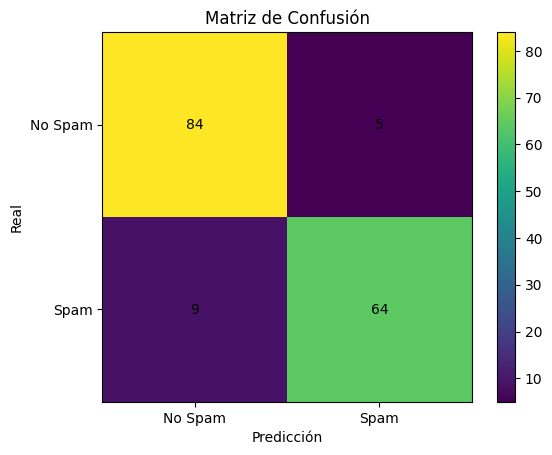

In [32]:
cm = confusion_matrix(y_test, y_pred)


plt.imshow(cm)
plt.title("Matriz de Confusión")
plt.colorbar()

plt.xticks([0,1], ['No Spam', 'Spam'])
plt.yticks([0,1], ['No Spam', 'Spam'])

plt.xlabel('Predicción')
plt.ylabel('Real')

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()